In [1]:
from google.colab import files
uploaded = files.upload()

Saving Scene Classification-20260509T132743Z-3-001.zip to Scene Classification-20260509T132743Z-3-001 (1).zip


In [2]:
import zipfile

# This opens the zip and extracts all images into /content/data folder
with zipfile.ZipFile('/content/Scene Classification-20260509T132743Z-3-001.zip', 'r') as z:
    z.extractall('/content/data')

print("Extraction complete!")

# These are the folder paths where your images now live
TRAIN_DIR = '/content/data/Scene Classification/train'
TEST_DIR  = '/content/data/Scene Classification/test'

# These are your 6 categories
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
print("Classes:", CLASSES)

Extraction complete!
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [3]:
import os                   # for reading folders/files
import numpy as np          # for number operations
import matplotlib.pyplot as plt  # for drawing graphs and images
import seaborn as sns       # for better-looking graphs
import time                 # for measuring training time
import tensorflow as tf     # the main deep learning library

from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Count how many images exist in each class folder
counts_train = {}
counts_test  = {}

for cls in CLASSES:
    counts_train[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    counts_test[cls]  = len(os.listdir(os.path.join(TEST_DIR,  cls)))

print("=== TRAINING SET ===")
for cls, count in counts_train.items():
    print(f"  {cls:12s}: {count} images")
print(f"  TOTAL      : {sum(counts_train.values())} images")

print("\n=== TEST SET ===")
for cls, count in counts_test.items():
    print(f"  {cls:12s}: {count} images")
print(f"  TOTAL      : {sum(counts_test.values())} images")

=== TRAINING SET ===
  buildings   : 2191 images
  forest      : 2271 images
  glacier     : 2404 images
  mountain    : 2512 images
  sea         : 2274 images
  street      : 2382 images
  TOTAL      : 14034 images

=== TEST SET ===
  buildings   : 437 images
  forest      : 474 images
  glacier     : 553 images
  mountain    : 525 images
  sea         : 510 images
  street      : 501 images
  TOTAL      : 3000 images


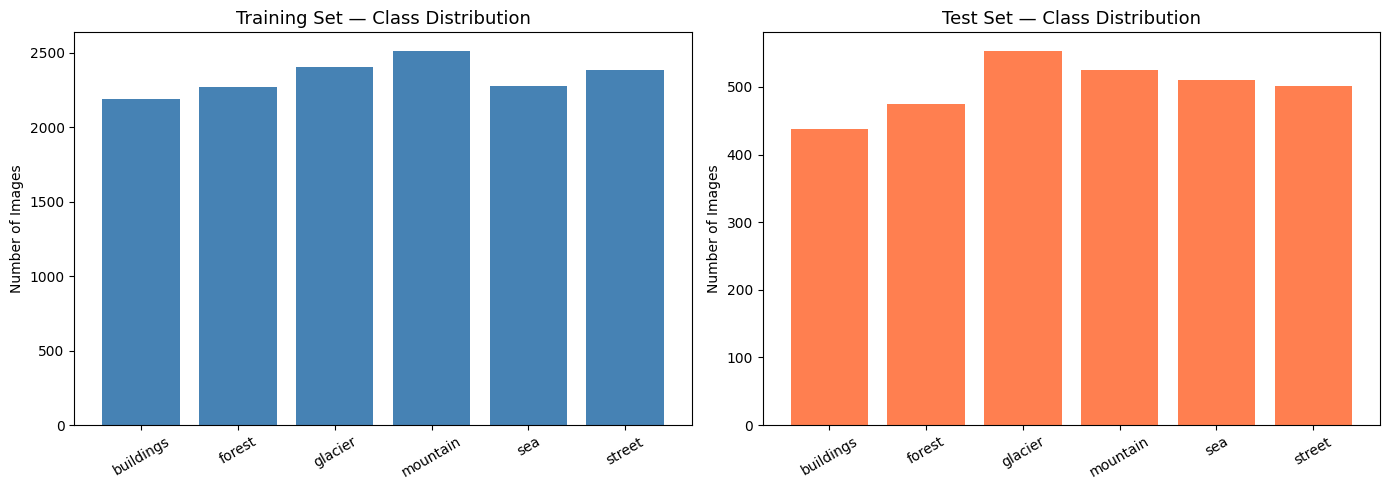

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set bar chart
axes[0].bar(counts_train.keys(), counts_train.values(), color='steelblue')
axes[0].set_title('Training Set — Class Distribution', fontsize=13)
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)

# Test set bar chart
axes[1].bar(counts_test.keys(), counts_test.values(), color='coral')
axes[1].set_title('Test Set — Class Distribution', fontsize=13)
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Write this observation in your report:
# "The dataset is well-balanced with approximately 2200-2500 images per class in training"

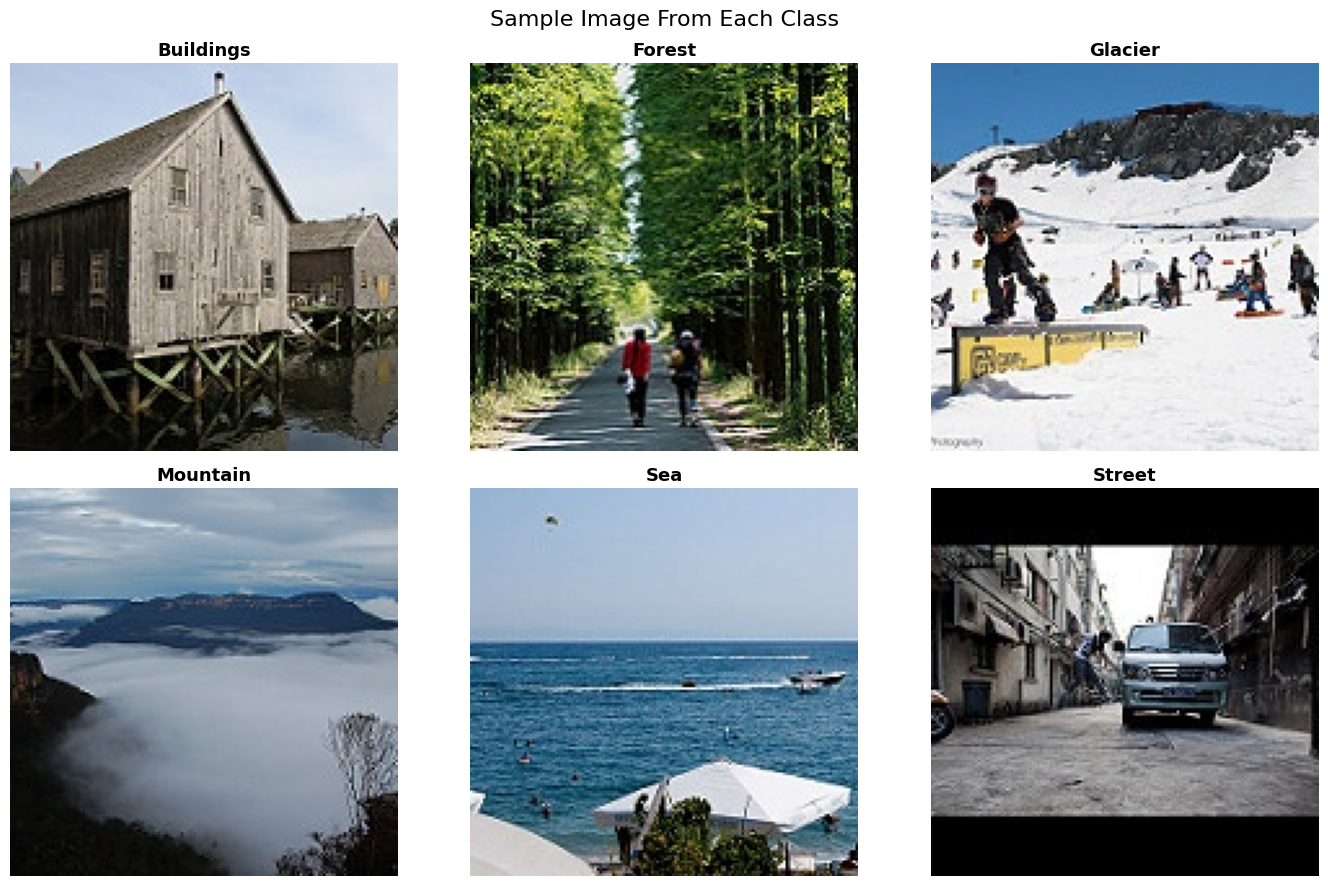

In [6]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, cls in zip(axes.flatten(), CLASSES):
    folder   = os.path.join(TRAIN_DIR, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(cls.capitalize(), fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Image From Each Class', fontsize=16)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [7]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32   # process 32 images at a time

# Training generator — includes augmentation and splits 80% train / 20% validation
train_datagen = ImageDataGenerator(
    rescale          = 1./255,    # normalize pixels 0-255 → 0-1
    validation_split = 0.2,       # use 20% of train data for validation
    horizontal_flip  = True,      # randomly flip images left-right
    zoom_range       = 0.2,       # randomly zoom in/out
    rotation_range   = 15,        # randomly rotate up to 15 degrees
    width_shift_range  = 0.1,     # randomly shift left/right
    height_shift_range = 0.1      # randomly shift up/down
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',  # 6 classes = categorical
    subset       = 'training',
    seed         = 42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = 42
)

# Test generator — NO augmentation, just rescale
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False           # keep order for evaluation
)

print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples      : {test_gen.samples}")

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Training samples  : 11230
Validation samples: 2804
Test samples      : 3000


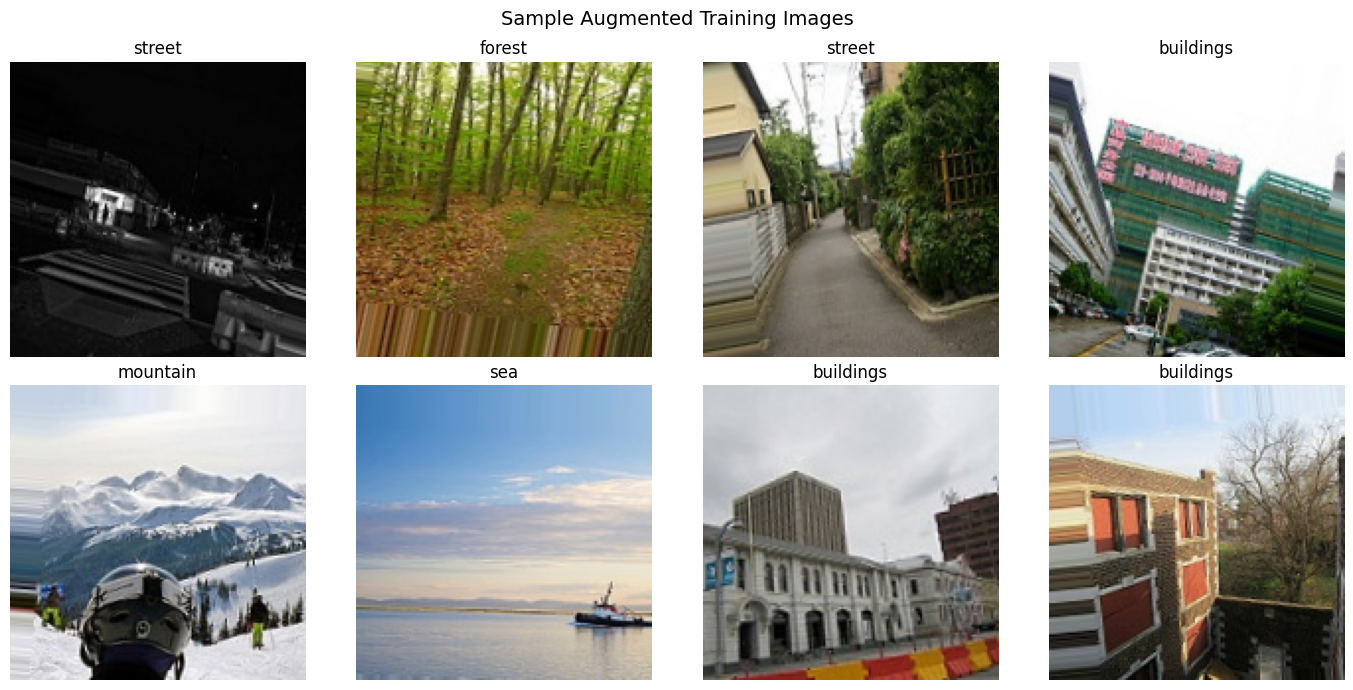

In [8]:
# Grab one batch to visualize
sample_images, sample_labels = next(train_gen)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    ax.set_title(CLASSES[np.argmax(sample_labels[i])])
    ax.axis('off')

plt.suptitle('Sample Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

In [9]:
def plot_history(history, title):
    """
    Plots training vs validation accuracy and loss.
    history = what model.fit() returns
    title   = name of the model (for the chart title)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss plot
    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

In [10]:
def evaluate_model(model, test_gen, title):
    """
    Runs model on test data and prints accuracy, F1 score, confusion matrix.
    """
    test_gen.reset()  # always reset before predicting

    # Get predictions
    preds  = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)   # predicted class index
    y_true = test_gen.classes            # actual class index

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # Confusion matrix — shows which classes get confused
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} — Confusion Matrix')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_cm.png', dpi=150)
    plt.show()

In [11]:
model_baseline = models.Sequential([

    # Block 1 — detect simple features like edges
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    # 32 filters, each 3x3 pixels, relu = ignore negatives
    layers.MaxPooling2D(2, 2),
    # shrink image by half (150→75)

    # Block 2 — detect more complex features
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    # 75 → 37

    # Block 3 — detect even more complex features
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    # 37 → 18

    # Flatten — convert to 1D
    layers.Flatten(),

    # 3 Fully Connected layers — make the decision
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),

    # Output — 6 neurons (one per class), softmax gives probabilities
    layers.Dense(6, activation='softmax')

], name='Baseline_CNN')

model_baseline.summary()
# Look at "Total params" — this tells you model size

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,604,998 (36.64 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from PIL import Image
import os

def clean_bad_images(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            try:
                img = Image.open(filepath)
                img.verify()  # check if image is valid
            except Exception:
                print(f"❌ Removing bad image: {filepath}")
                os.remove(filepath)
                removed += 1
    print(f"\n✅ Done! Removed {removed} bad images.")

print("Scanning TRAIN folder...")
clean_bad_images(TRAIN_DIR)

print("\nScanning TEST folder...")
clean_bad_images(TEST_DIR)

Scanning TRAIN folder...
❌ Removing bad image: /content/data/Scene Classification/train/forest/7595.jpg
❌ Removing bad image: /content/data/Scene Classification/train/forest/8162.jpg
❌ Removing bad image: /content/data/Scene Classification/train/forest/134.jpg
❌ Removing bad image: /content/data/Scene Classification/train/forest/5818.jpg
❌ Removing bad image: /content/data/Scene Classification/train/forest/1554.jpg
❌ Removing bad image: /content/data/Scene Classification/train/forest/6746.jpg
❌ Removing bad image: /content/data/Scene Classification/train/forest/11977.jpg
❌ Removing bad image: /content/data/Scene Classification/train/sea/6369.jpg
❌ Removing bad image: /content/data/Scene Classification/train/sea/916.jpg
❌ Removing bad image: /content/data/Scene Classification/train/sea/3041.jpg
❌ Removing bad image: /content/data/Scene Classification/train/sea/17040.jpg
❌ Removing bad image: /content/data/Scene Classification/train/sea/10948.jpg
❌ Removing bad image: /content/data/Scene

In [13]:
# IMPORTANT: Re-create generators after removing bad images
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("✅ Generators recreated!")

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
✅ Generators recreated!


In [14]:
# Compile = set how model learns
model_baseline.compile(
    optimizer = 'adam',                    # adam = smart learning rate
    loss      = 'categorical_crossentropy',# standard loss for multi-class
    metrics   = ['accuracy']
)

# EarlyStopping = stop training if model stops improving (prevents wasting time)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# patience=5 means: stop if no improvement for 5 epochs in a row

start = time.time()

history_baseline = model_baseline.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 30,      # maximum 30 rounds of training
    callbacks       = [es]     # use early stopping
)

baseline_time = time.time() - start
print(f"\n✅ Baseline Training Time: {baseline_time/60:.1f} minutes")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 96s 258ms/step - accuracy: 0.5640 - loss: 1.0981 - val_accuracy: 0.6656 - val_loss: 0.8976
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - accuracy: 0.6877 - loss: 0.8326 - val_accuracy: 0.7375 - val_loss: 0.7050
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 99s 284ms/step - accuracy: 0.7450 - loss: 0.6945 - val_accuracy: 0.7335 - val_loss: 0.7300
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 253ms/step - accuracy: 0.7636 - loss: 0.6392 - val_accuracy: 0.7775 - val_loss: 0.5951
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 87s 249ms/step - accuracy: 0.7893 - loss: 0.5834 - val_accuracy: 0.8069 - val_loss: 0.5587
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 241ms/step - accuracy: 0.7973 - loss: 0.5594 - val_accuracy: 0.8044 - val_loss: 0.5591
Epoch 7/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 244ms/step - accuracy: 0.8131 - loss: 0.5150 - val_accuracy: 0.8133 - val_loss: 0.5282
Epoch 8/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 243ms/step - accuracy: 0.8207 - loss: 0

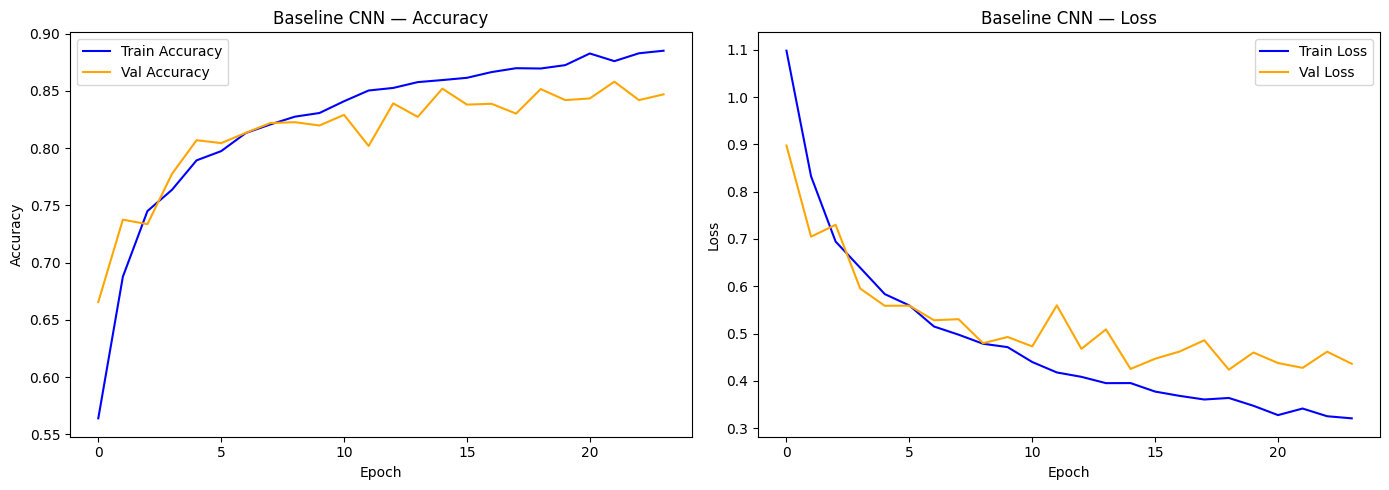

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step

  Baseline CNN
              precision    recall  f1-score   support

   buildings       0.82      0.88      0.85       437
      forest       0.95      0.97      0.96       474
     glacier       0.88      0.73      0.80       553
    mountain       0.76      0.86      0.80       525
         sea       0.85      0.87      0.86       510
      street       0.88      0.84      0.86       501

    accuracy                           0.85      3000
   macro avg       0.86      0.86      0.85      3000
weighted avg       0.86      0.85      0.85      3000



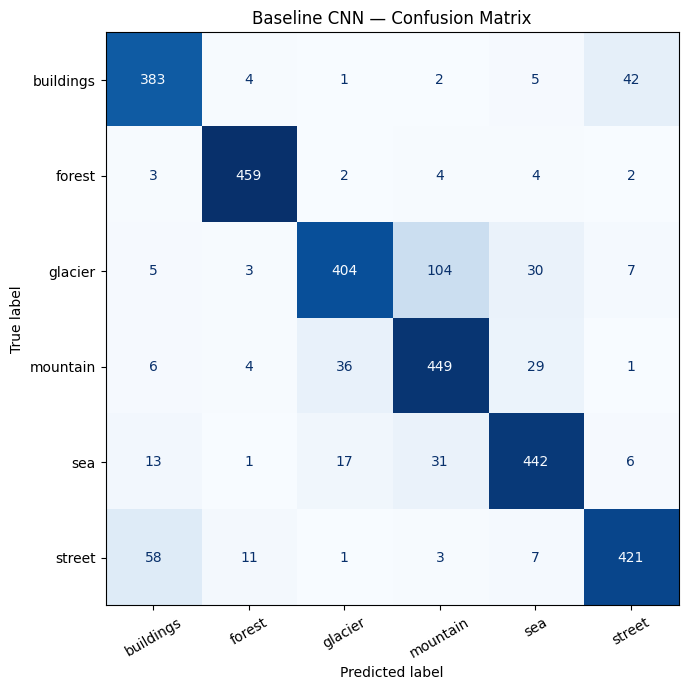

In [15]:
plot_history(history_baseline, 'Baseline CNN')
evaluate_model(model_baseline, test_gen, 'Baseline CNN')

In [16]:
def build_deep_model():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 4 — extra (baseline had only 3 blocks)
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 5 — extra
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # Block 6 — extra
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.Flatten(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),   # turn off 50% neurons randomly
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),   # turn off 30% neurons randomly
        layers.Dense(128, activation='relu'),
        layers.Dense(6, activation='softmax')

    ], name='Deep_CNN')
    return model

model_deep_adam = build_deep_model()
model_deep_adam.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 9, 9, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,89

 Total params: 23,562,822 (89.89 MB)

 Trainable params: 23,560,326 (89.88 MB)

 Non-trainable params: 2,496 (9.75 KB)

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 123s 311ms/step - accuracy: 0.3721 - loss: 2.8590 - val_accuracy: 0.2650 - val_loss: 1.9217
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.5345 - loss: 1.1650 - val_accuracy: 0.6524 - val_loss: 0.9879
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.6589 - loss: 0.9390 - val_accuracy: 0.5036 - val_loss: 1.4514
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 267ms/step - accuracy: 0.7019 - loss: 0.8346 - val_accuracy: 0.5469 - val_loss: 1.2961
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.7374 - loss: 0.7593 - val_accuracy: 0.6795 - val_loss: 0.9184
✅ Deep CNN (Adam) Training Time: 8.4 minutes


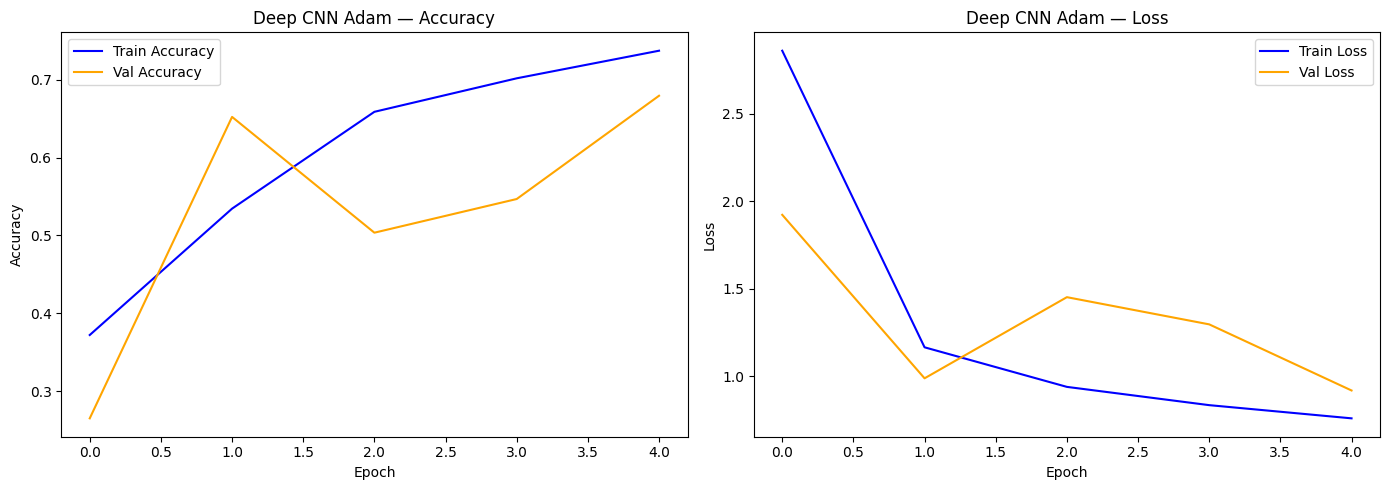

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step

  Deep CNN Adam
              precision    recall  f1-score   support

   buildings       0.19      0.03      0.05       437
      forest       0.93      0.39      0.55       474
     glacier       0.23      0.81      0.35       553
    mountain       0.40      0.28      0.33       525
         sea       0.29      0.19      0.23       510
      street       0.67      0.07      0.12       501

    accuracy                           0.31      3000
   macro avg       0.45      0.29      0.27      3000
weighted avg       0.45      0.31      0.28      3000



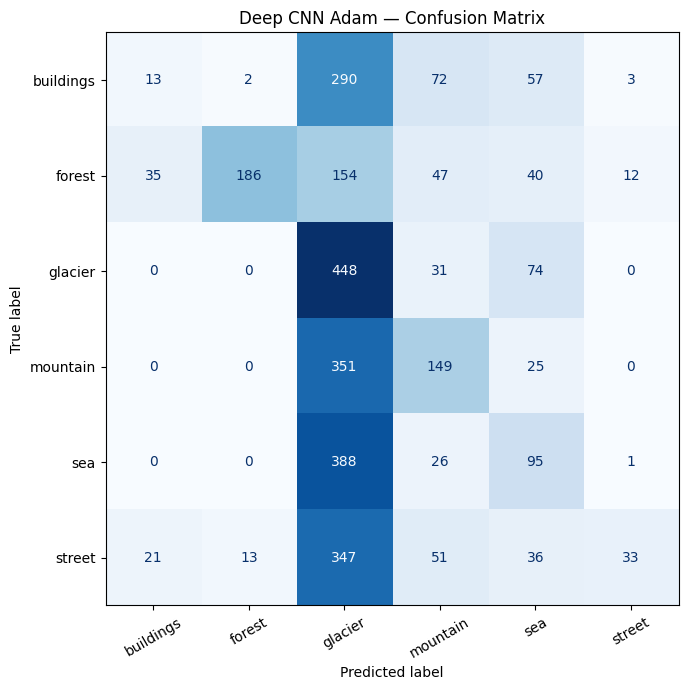

In [17]:
model_deep_adam.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

start = time.time()
history_deep_adam = model_deep_adam.fit(
    train_gen, validation_data=val_gen,
    epochs=30, callbacks=[es]
)
deep_adam_time = time.time() - start
print(f"✅ Deep CNN (Adam) Training Time: {deep_adam_time/60:.1f} minutes")

plot_history(history_deep_adam, 'Deep CNN Adam')
evaluate_model(model_deep_adam, test_gen, 'Deep CNN Adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 109s 288ms/step - accuracy: 0.4147 - loss: 1.5504 - val_accuracy: 0.4950 - val_loss: 1.3177
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 273ms/step - accuracy: 0.5168 - loss: 1.2401 - val_accuracy: 0.5680 - val_loss: 1.1102
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.5757 - loss: 1.1098 - val_accuracy: 0.5694 - val_loss: 1.0830
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.6038 - loss: 1.0586 - val_accuracy: 0.6062 - val_loss: 1.0779
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.6656 - loss: 0.9500 - val_accuracy: 0.6695 - val_loss: 0.9274
✅ Deep CNN (SGD) Training Time: 8.2 minutes


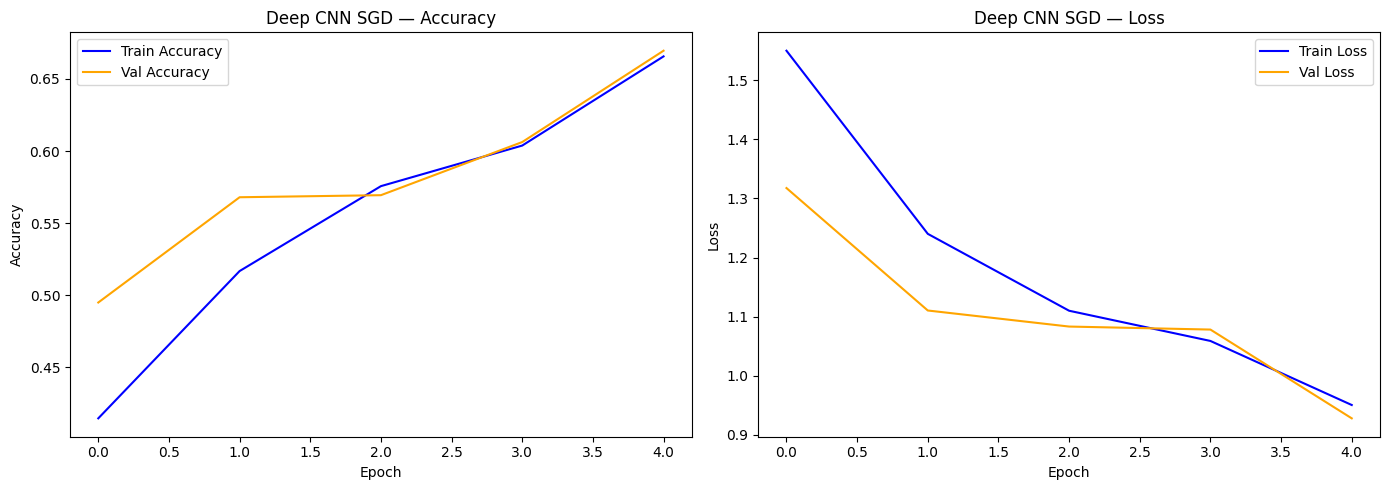

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step

  Deep CNN SGD
              precision    recall  f1-score   support

   buildings       0.49      0.59      0.54       437
      forest       0.76      0.79      0.78       474
     glacier       0.42      0.73      0.53       553
    mountain       0.56      0.32      0.41       525
         sea       0.38      0.38      0.38       510
      street       0.76      0.34      0.47       501

    accuracy                           0.52      3000
   macro avg       0.56      0.52      0.52      3000
weighted avg       0.56      0.52      0.51      3000



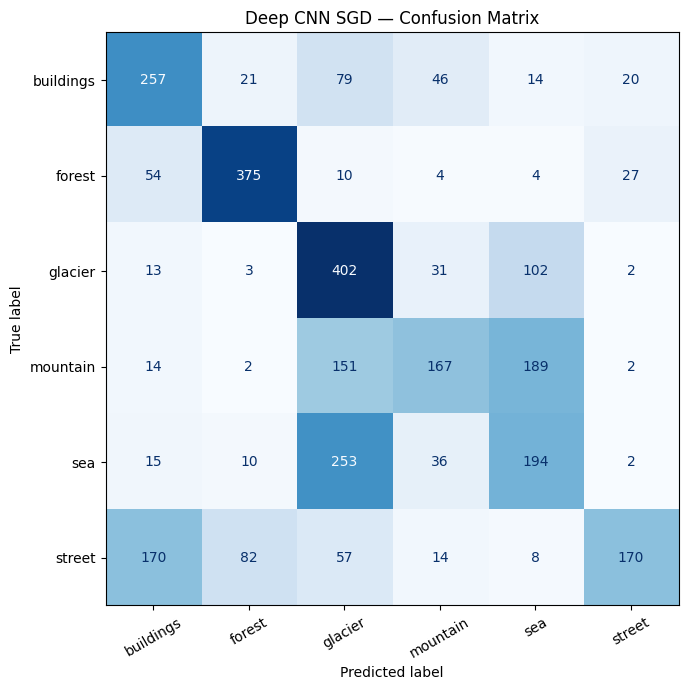

In [18]:
model_deep_sgd = build_deep_model()
model_deep_sgd.compile(
    optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

start = time.time()
history_deep_sgd = model_deep_sgd.fit(
    train_gen, validation_data=val_gen,
    epochs=30, callbacks=[es]
)
deep_sgd_time = time.time() - start
print(f"✅ Deep CNN (SGD) Training Time: {deep_sgd_time/60:.1f} minutes")

plot_history(history_deep_sgd, 'Deep CNN SGD')
evaluate_model(model_deep_sgd, test_gen, 'Deep CNN SGD')

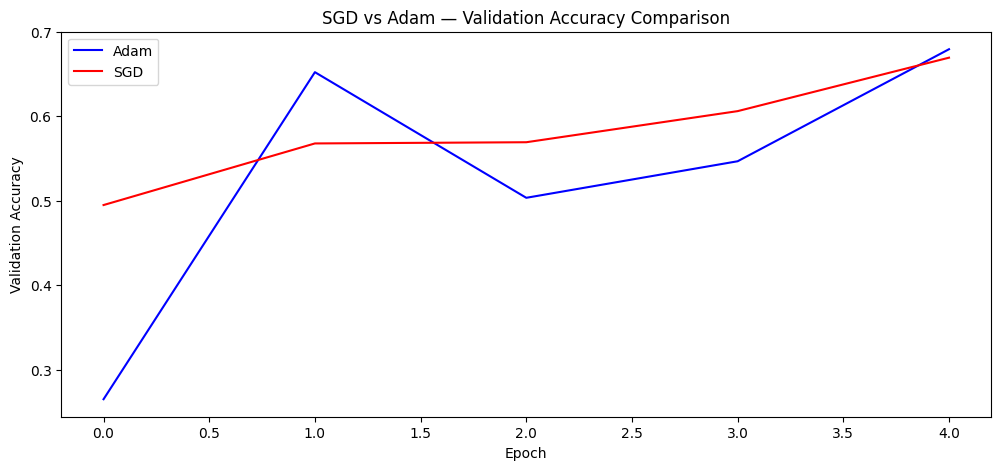

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(history_deep_adam.history['val_accuracy'], label='Adam', color='blue')
plt.plot(history_deep_sgd.history['val_accuracy'],  label='SGD',  color='red')
plt.title('SGD vs Adam — Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.savefig('sgd_vs_adam.png', dpi=150)
plt.show()
# In your report: which converged faster? which reached higher accuracy?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 110s 288ms/step - accuracy: 0.5624 - loss: 1.3958 - val_accuracy: 0.2285 - val_loss: 3.6950
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 267ms/step - accuracy: 0.6964 - loss: 0.8134 - val_accuracy: 0.6695 - val_loss: 0.8606
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - accuracy: 0.7546 - loss: 0.6785 - val_accuracy: 0.5991 - val_loss: 1.3302
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 267ms/step - accuracy: 0.7773 - loss: 0.6143 - val_accuracy: 0.3491 - val_loss: 2.8692
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 265ms/step - accuracy: 0.7974 - loss: 0.5610 - val_accuracy: 0.6888 - val_loss: 0.9290


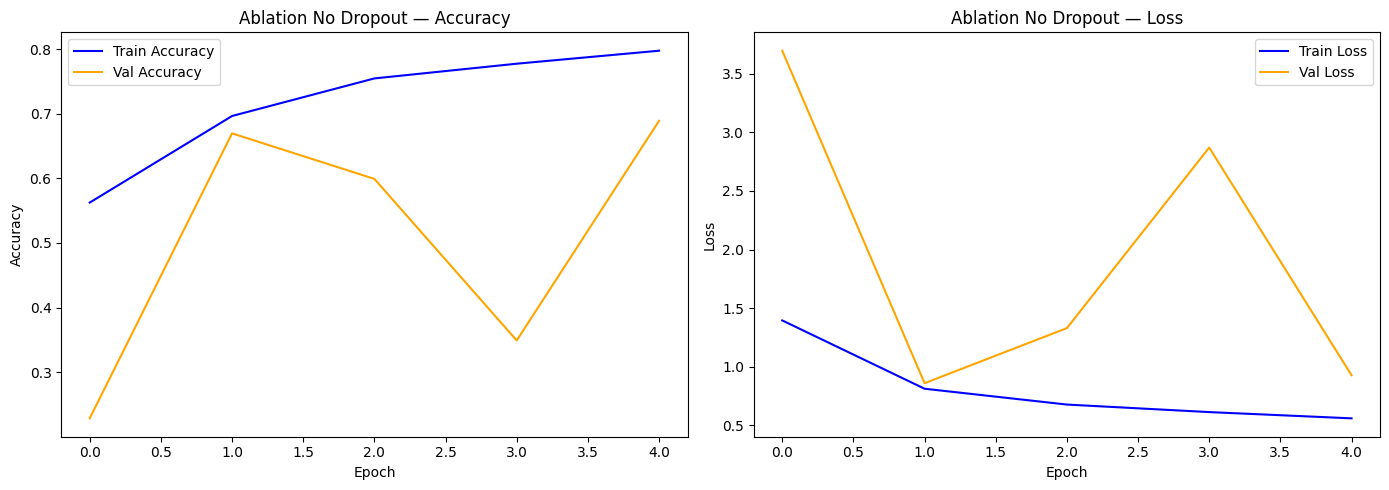

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

  Ablation No Dropout
              precision    recall  f1-score   support

   buildings       0.77      0.02      0.04       437
      forest       0.99      0.28      0.44       474
     glacier       0.02      0.00      0.01       553
    mountain       0.23      0.31      0.26       525
         sea       0.24      0.95      0.39       510
      street       0.68      0.09      0.16       501

    accuracy                           0.28      3000
   macro avg       0.49      0.28      0.22      3000
weighted avg       0.47      0.28      0.22      3000



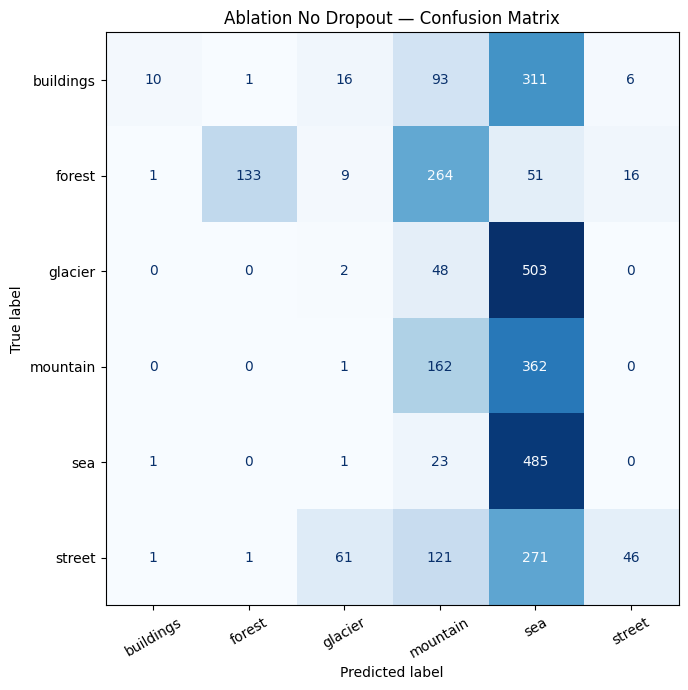

In [20]:
def build_deep_no_dropout():
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),  # NO Dropout
        layers.Dense(256, activation='relu'),  # NO Dropout
        layers.Dense(128, activation='relu'),
        layers.Dense(6,   activation='softmax')
    ], name='Deep_No_Dropout')
    return model

model_ablation = build_deep_no_dropout()
model_ablation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ablation = model_ablation.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=[es])

plot_history(history_ablation, 'Ablation No Dropout')
evaluate_model(model_ablation, test_gen, 'Ablation No Dropout')
# If val accuracy is LOWER = dropout was helping prevent overfitting

In [21]:
train_datagen_tl = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    horizontal_flip=True, zoom_range=0.2
)

train_gen_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42
)
val_gen_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', seed=42
)
test_gen_tl = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', shuffle=False
)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 layers: 175


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 212s 566ms/step - accuracy: 0.3181 - loss: 1.5588 - val_accuracy: 0.3827 - val_loss: 1.3795
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 183s 523ms/step - accuracy: 0.3876 - loss: 1.3800 - val_accuracy: 0.4514 - val_loss: 1.3036
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 521ms/step - accuracy: 0.4350 - loss: 1.3195 - val_accuracy: 0.5072 - val_loss: 1.2567
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 519ms/step - accuracy: 0.4555 - loss: 1.2788 - val_accuracy: 0.5046 - val_loss: 1.2070
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 521ms/step - accuracy: 0.4802 - loss: 1.2333 - val_accuracy: 0.5522 - val_loss: 1.1829


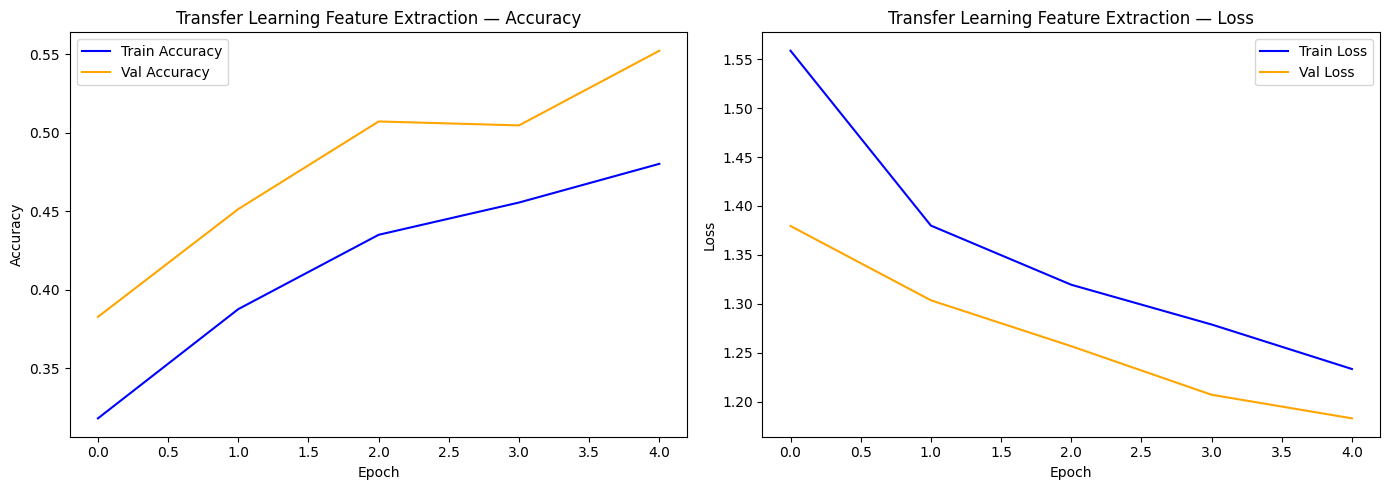

In [22]:
# Load ResNet50 pretrained on ImageNet, remove its top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # FREEZE — don't change ResNet weights yet
print(f"ResNet50 layers: {len(base_model.layers)}")

# Add our own classification head on top
inputs  = keras.Input(shape=(224,224,3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)  # compress features
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation='softmax')(x)  # our 6 classes

model_tl = Model(inputs, outputs, name='ResNet50_Transfer')
model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_tl.summary()

history_tl = model_tl.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=15, callbacks=[es]
)
plot_history(history_tl, 'Transfer Learning Feature Extraction')

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 215s 563ms/step - accuracy: 0.5152 - loss: 1.1839 - val_accuracy: 0.5315 - val_loss: 1.2910
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 184s 525ms/step - accuracy: 0.6452 - loss: 0.9131 - val_accuracy: 0.6956 - val_loss: 0.7993
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 187s 533ms/step - accuracy: 0.6906 - loss: 0.8218 - val_accuracy: 0.7089 - val_loss: 0.7520
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 183s 524ms/step - accuracy: 0.7100 - loss: 0.7747 - val_accuracy: 0.7067 - val_loss: 0.7817
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 184s 526ms/step - accuracy: 0.7204 - loss: 0.7438 - val_accuracy: 0.7271 - val_loss: 0.7179


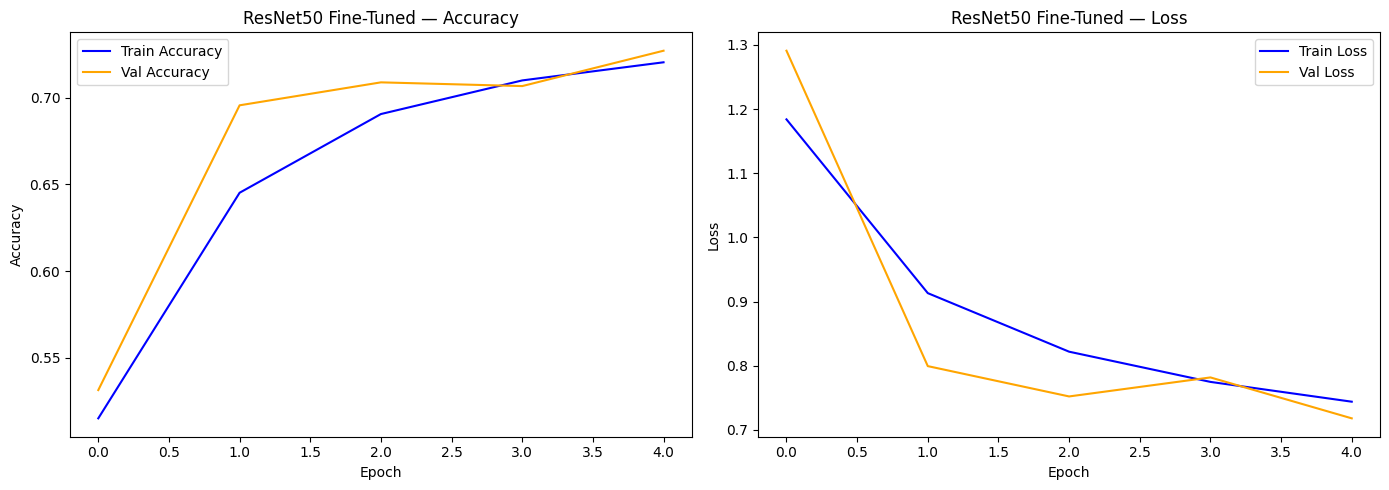

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step

  ResNet50 Fine-Tuned
              precision    recall  f1-score   support

   buildings       0.62      0.60      0.61       437
      forest       0.83      0.69      0.75       474
     glacier       0.47      0.27      0.34       553
    mountain       0.38      0.72      0.50       525
         sea       0.52      0.38      0.44       510
      street       0.62      0.61      0.61       501

    accuracy                           0.54      3000
   macro avg       0.57      0.54      0.54      3000
weighted avg       0.57      0.54      0.53      3000



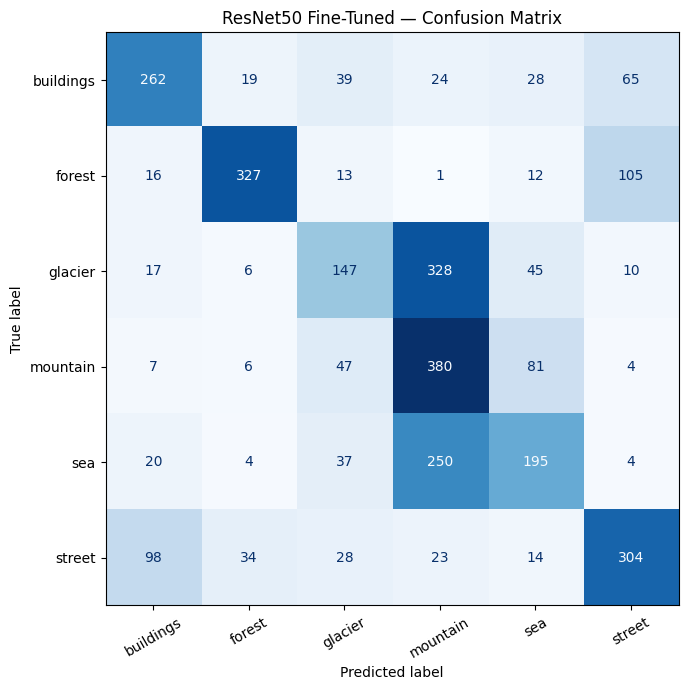

In [23]:
# Unfreeze last 20 layers of ResNet to let them adapt to our data
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False  # keep early layers frozen

# Use VERY small learning rate — avoid destroying pretrained weights
model_tl.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history_tl_ft = model_tl.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=10, callbacks=[es]
)
plot_history(history_tl_ft, 'ResNet50 Fine-Tuned')
evaluate_model(model_tl, test_gen_tl, 'ResNet50 Fine-Tuned')


========== FINAL RESULTS ==========
  Baseline CNN              → 85.27% accuracy
  Deep CNN (Adam)           → 30.8% accuracy
  Deep CNN (SGD)            → 52.17% accuracy
  No Dropout                → 27.93% accuracy
  ResNet50 Fine-Tuned       → 53.83% accuracy


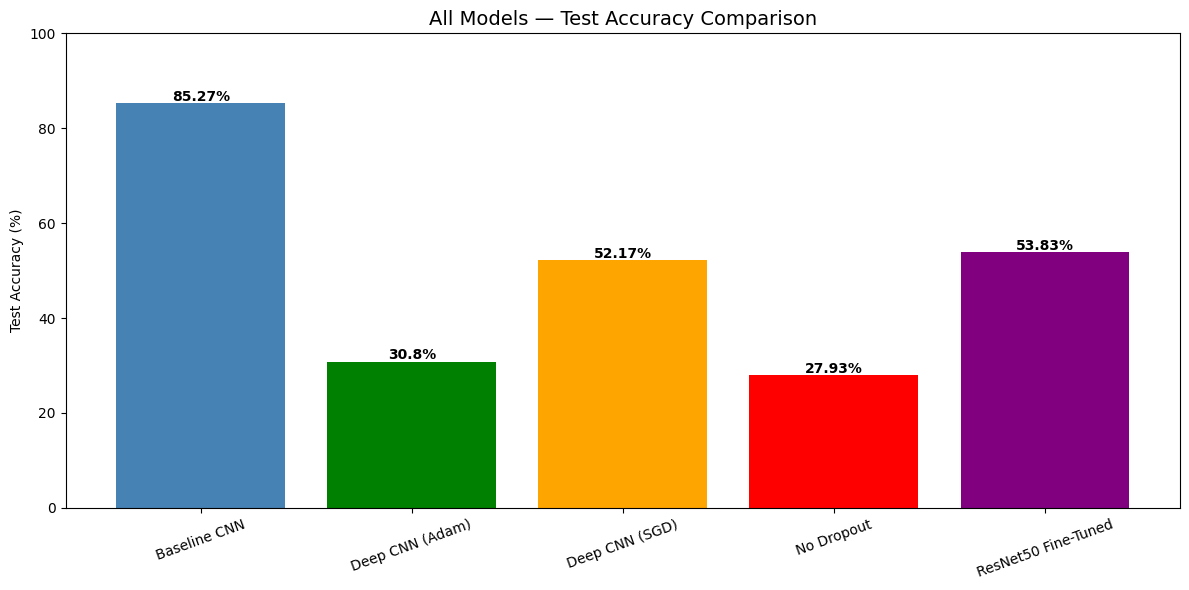

In [24]:
# Get test accuracy for every model
results = {}
for name, mdl, tgen in [
    ('Baseline CNN',        model_baseline,  test_gen),
    ('Deep CNN (Adam)',     model_deep_adam, test_gen),
    ('Deep CNN (SGD)',      model_deep_sgd,  test_gen),
    ('No Dropout',          model_ablation,  test_gen),
    ('ResNet50 Fine-Tuned', model_tl,        test_gen_tl),
]:
    tgen.reset()
    _, acc = mdl.evaluate(tgen, verbose=0)
    results[name] = round(acc * 100, 2)

print("\n========== FINAL RESULTS ==========")
for name, acc in results.items():
    print(f"  {name:<25} → {acc}% accuracy")

# Bar chart
colors = ['steelblue', 'green', 'orange', 'red', 'purple']
plt.figure(figsize=(12, 6))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.title('All Models — Test Accuracy Comparison', fontsize=14)
plt.ylabel('Test Accuracy (%)')
plt.xticks(rotation=20)
plt.ylim(0, 100)
for bar, (k, v) in zip(bars, results.items()):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

In [25]:
model_baseline.save('baseline_cnn.h5')
model_deep_adam.save('deep_cnn_adam.h5')
model_tl.save('resnet50_finetuned.h5')
print("All models saved!")

All models saved!
